# EE 391, Lecture 11 — Continuous Random Variables

**Accompanying figures for the lecture deck.**

This notebook builds 12 figures keyed to the slides:

| Slide | Plot | Filename |
|---|---|---|
| 5 | Generic PDF with shaded area $P(a \leq X \leq b)$ | `01_pdf_intuition.png` |
| 5 | $f(x) = 1/(2\sqrt{x})$ — PDF unbounded but area = 1 | `02_pdf_unbounded.png` |
| 6 | Continuous uniform on $[0,1]$ and $[2,5]$ | `03_uniform.png` |
| 7 | Alvin's commute — piecewise constant | `04_alvin.png` |
| 8 | Knowledge check Q2 — $f(x) = 8x$ | `05_quiz_q2.png` |
| 10 | Triangular voltage worked example | `06_triangle.png` |
| 11 | Exponential PDF for three rates | `07_exp_rates.png` |
| 11 | Meteorite first-strike example | `08_meteorite.png` |
| 13/14 | Discrete vs continuous CDF, side by side | `09_cdf_compare.png` |
| 15 | Geometric vs exponential CDF — same shape | `10_geo_vs_exp.png` |
| 15 | Median vs mean of the exponential | `11_median_vs_mean.png` |
| 16 (opt.) | Memoryless property — conditional density | `12_memoryless.png` |

Run cells top-to-bottom. Each plot saves a 200 dpi PNG into `figures/` and renders inline.


## Setup — imports, styling, output directory

One consistent palette across all figures so the deck looks coherent.

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Slide-friendly defaults
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.figsize': (8, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 100,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'mathtext.fontset': 'cm',
})

# Color palette
C_PDF    = '#1f4e79'   # primary curves
C_FILL   = '#aac7e6'   # shaded probability regions
C_MEAN   = '#c5504b'   # mean / annotations
C_MEDIAN = '#ed7d31'   # median
C_GREY   = '#888888'   # secondary references
C_ALT1   = '#70ad47'   # second curve
C_ALT2   = '#7030a0'   # third curve

os.makedirs('figures', exist_ok=True)
print('Setup complete. Figures will be saved to ./figures/')


Setup complete. Figures will be saved to ./figures/


## Slide 5 — Probability of an interval is the area under the PDF

The picture you'll draw on the board live, but useful as a reference. A smooth density with the interval $[a, b]$ shaded so students can see the area = probability connection at a glance.

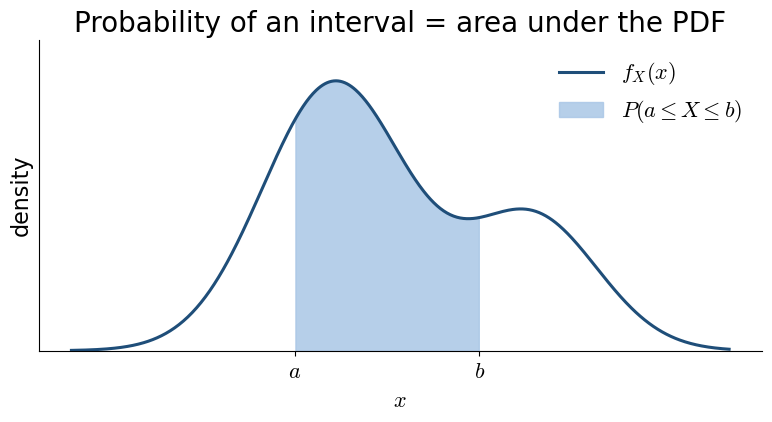

In [15]:
x = np.linspace(-0.5, 4.5, 600)
pdf = 0.6 * np.exp(-((x - 1.5) ** 2) / 0.6) + 0.3 * np.exp(-((x - 3) ** 2) / 0.5)
pdf = pdf / np.trapezoid(pdf, x)

a, b = 1.2, 2.6
mask = (x >= a) & (x <= b)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, pdf, color=C_PDF, lw=2.2, label=r'$f_X(x)$')
ax.fill_between(x[mask], 0, pdf[mask], color=C_FILL, alpha=0.85,
                label=r'$P(a \leq X \leq b)$')
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks([a, b]); ax.set_xticklabels(['$a$', '$b$'])
ax.set_yticks([])
ax.set_xlabel('$x$')
ax.set_ylabel('density')
ax.set_title('Probability of an interval = area under the PDF')
ax.legend(loc='upper right', frameon=False)
ax.set_ylim(0, max(pdf) * 1.15)
fig.tight_layout()
fig.savefig('figures/01_pdf_intuition.png')
plt.show()


## Slide 5 — A PDF can exceed 1

Forestalls the most common misconception. The function $f(x) = 1/(2\sqrt{x})$ on $(0, 1]$ blows up near zero yet integrates to 1. Use this when introducing the "density vs probability" distinction, and again to debrief Q2 of the knowledge check.

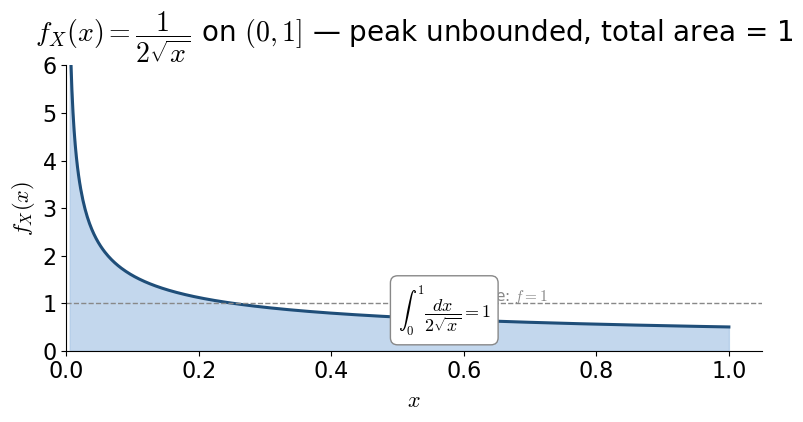

In [16]:
x = np.linspace(0.005, 1.0, 600)
pdf = 1.0 / (2.0 * np.sqrt(x))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, pdf, color=C_PDF, lw=2.2)
ax.fill_between(x, 0, pdf, color=C_FILL, alpha=0.7)
ax.axhline(1.0, color=C_GREY, lw=1.0, ls='--')
ax.text(0.55, 1.05, 'reference: $f = 1$', color=C_GREY, fontsize=11)
ax.set_xlabel('$x$'); ax.set_ylabel('$f_X(x)$')
ax.set_xlim(0, 1.05); ax.set_ylim(0, 6)
ax.set_title(r'$f_X(x) = \dfrac{1}{2\sqrt{x}}$ on $(0, 1]$ — peak unbounded, total area = 1')
ax.annotate(r'$\int_0^1 \dfrac{dx}{2\sqrt{x}} = 1$',
            xy=(0.5, 0.7), fontsize=13,
            bbox=dict(facecolor='white', edgecolor=C_GREY, boxstyle='round,pad=0.4'))
fig.tight_layout()
fig.savefig('figures/02_pdf_unbounded.png')
plt.show()


## Slide 6 — Continuous uniform PDF

Two panels: $\text{Uniform}[0,1]$ with height 1, and $\text{Uniform}[2,5]$ with height $1/3$. Reinforces that the constant density depends on the interval width via normalization.

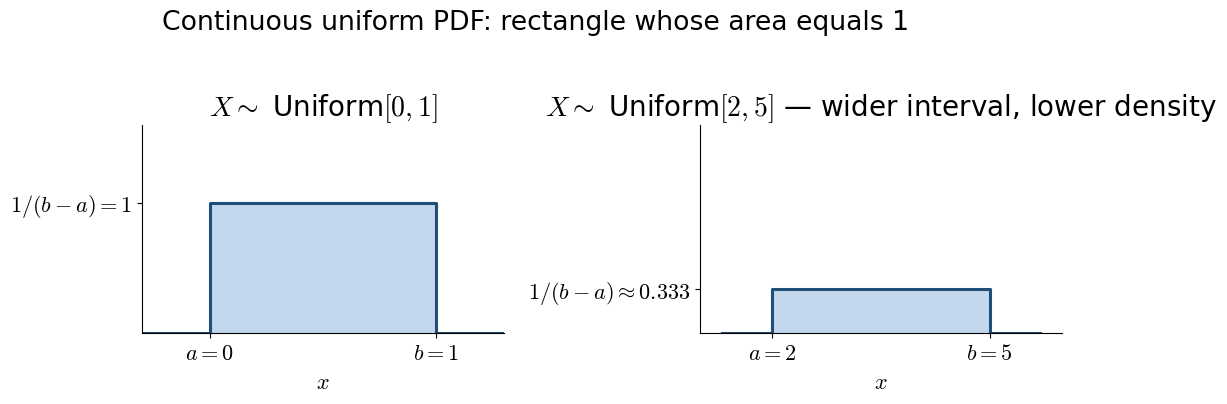

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Uniform[0, 1]
ax = axes[0]
a, b = 0.0, 1.0
height = 1.0 / (b - a)
ax.plot([a - 0.3, a, a, b, b, b + 0.3], [0, 0, height, height, 0, 0], color=C_PDF, lw=2.2)
ax.fill_between([a, b], 0, height, color=C_FILL, alpha=0.7)
ax.set_xlim(-0.3, 1.3); ax.set_ylim(0, 1.6)
ax.set_xticks([a, b]); ax.set_xticklabels(['$a=0$', '$b=1$'])
ax.set_yticks([height]); ax.set_yticklabels([f'$1/(b-a) = {height:.0f}$'])
ax.set_title(r'$X \sim$ Uniform$[0, 1]$')
ax.set_xlabel('$x$')

# Uniform[2, 5]
ax = axes[1]
a, b = 2.0, 5.0
height = 1.0 / (b - a)
ax.plot([a - 0.7, a, a, b, b, b + 0.7], [0, 0, height, height, 0, 0], color=C_PDF, lw=2.2)
ax.fill_between([a, b], 0, height, color=C_FILL, alpha=0.7)
ax.set_xlim(1, 6); ax.set_ylim(0, 1.6)
ax.set_xticks([a, b]); ax.set_xticklabels(['$a=2$', '$b=5$'])
ax.set_yticks([height]); ax.set_yticklabels([f'$1/(b-a) \\approx {height:.3f}$'])
ax.set_title(r'$X \sim$ Uniform$[2, 5]$ — wider interval, lower density')
ax.set_xlabel('$x$')

fig.suptitle('Continuous uniform PDF: rectangle whose area equals 1', y=1.02)
fig.tight_layout()
fig.savefig('figures/03_uniform.png')
plt.show()


## Slide 7 — Alvin's commute

Two-rectangle PDF showing that the *areas* (= the weather probabilities) split 2/3 vs 1/3 even though the heights split 2:1. Visually drives home the "density is not probability" point.

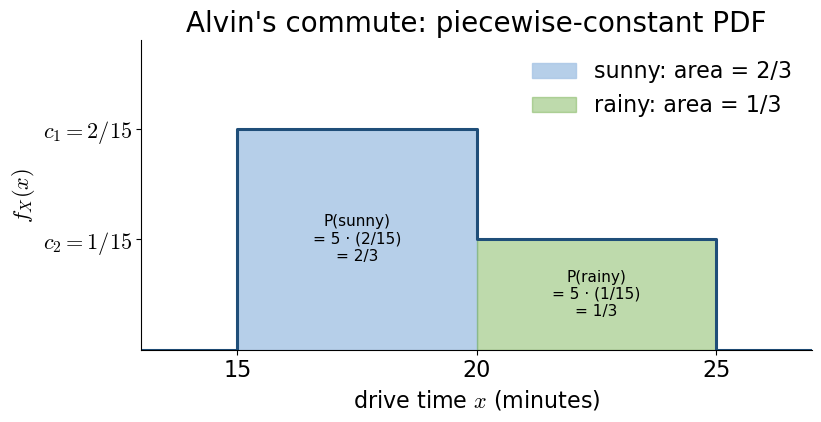

In [18]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
c1, c2 = 2/15, 1/15
xs = [13, 15, 15, 20, 20, 25, 25, 27]
ys = [0,  0,  c1, c1, c2, c2, 0,  0]
ax.plot(xs, ys, color=C_PDF, lw=2.2)
ax.fill_between([15, 20], 0, c1, color=C_FILL, alpha=0.85, label='sunny: area = 2/3')
ax.fill_between([20, 25], 0, c2, color=C_ALT1, alpha=0.45, label='rainy: area = 1/3')

ax.set_xlim(13, 27); ax.set_ylim(0, c1 * 1.4)
ax.set_xticks([15, 20, 25])
ax.set_yticks([c2, c1]); ax.set_yticklabels(['$c_2 = 1/15$', '$c_1 = 2/15$'])
ax.set_xlabel('drive time $x$ (minutes)')
ax.set_ylabel('$f_X(x)$')
ax.set_title("Alvin's commute: piecewise-constant PDF")
ax.legend(loc='upper right', frameon=False)

ax.text(17.5, c1/2, 'P(sunny)\n= 5 · (2/15)\n= 2/3', ha='center', va='center', fontsize=11)
ax.text(22.5, c2/2, 'P(rainy)\n= 5 · (1/15)\n= 1/3', ha='center', va='center', fontsize=11)
fig.tight_layout()
fig.savefig('figures/04_alvin.png')
plt.show()


## Slide 8 — Knowledge check Q2

Use after the Canvas poll closes to debrief. The dotted line at $f = 1$ is the misconception; the marked point at $(1/4, 2)$ is the punchline.

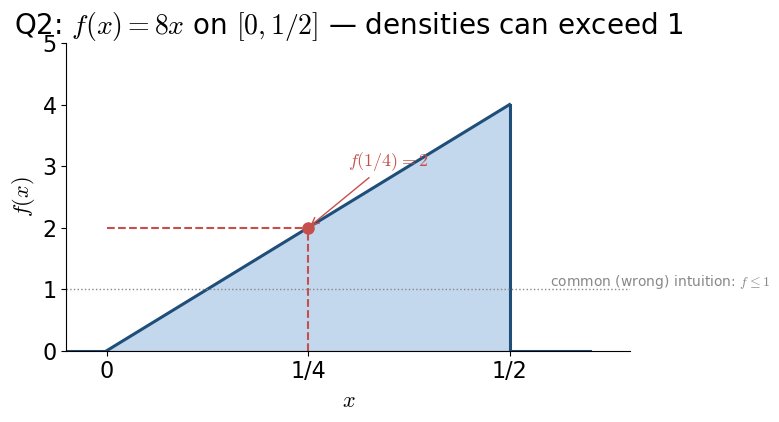

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.linspace(0, 0.5, 200)
pdf = 8 * x
ax.plot([-0.05, 0], [0, 0], color=C_PDF, lw=2.2)
ax.plot(x, pdf, color=C_PDF, lw=2.2)
ax.plot([0.5, 0.5], [4, 0], color=C_PDF, lw=2.2)
ax.plot([0.5, 0.6], [0, 0], color=C_PDF, lw=2.2)
ax.fill_between(x, 0, pdf, color=C_FILL, alpha=0.7)

ax.plot([0.25, 0.25], [0, 2], color=C_MEAN, lw=1.5, ls='--')
ax.plot([0, 0.25], [2, 2], color=C_MEAN, lw=1.5, ls='--')
ax.plot(0.25, 2, 'o', color=C_MEAN, ms=8)
ax.annotate('$f(1/4) = 2$', xy=(0.25, 2), xytext=(0.30, 3.0),
            fontsize=13, color=C_MEAN,
            arrowprops=dict(arrowstyle='->', color=C_MEAN))

ax.axhline(1.0, color=C_GREY, lw=1.0, ls=':')
ax.text(0.55, 1.05, r'common (wrong) intuition: $f \leq 1$', color=C_GREY, fontsize=10)

ax.set_xlim(-0.05, 0.65); ax.set_ylim(0, 5)
ax.set_xlabel('$x$'); ax.set_ylabel('$f(x)$')
ax.set_xticks([0, 0.25, 0.5]); ax.set_xticklabels(['0', '1/4', '1/2'])
ax.set_title(r'Q2: $f(x) = 8x$ on $[0, 1/2]$ — densities can exceed 1')
fig.tight_layout()
fig.savefig('figures/05_quiz_q2.png')
plt.show()


## Slide 10 — Triangular voltage worked example

The full worked-example visual: the triangle, the shaded $P(X > 1) = 1/4$ tail, and the mean $E[X] = 2/3$ marked. Notice the mean sits well left of the midpoint — mass is concentrated near zero, exactly what the triangle's shape suggests.

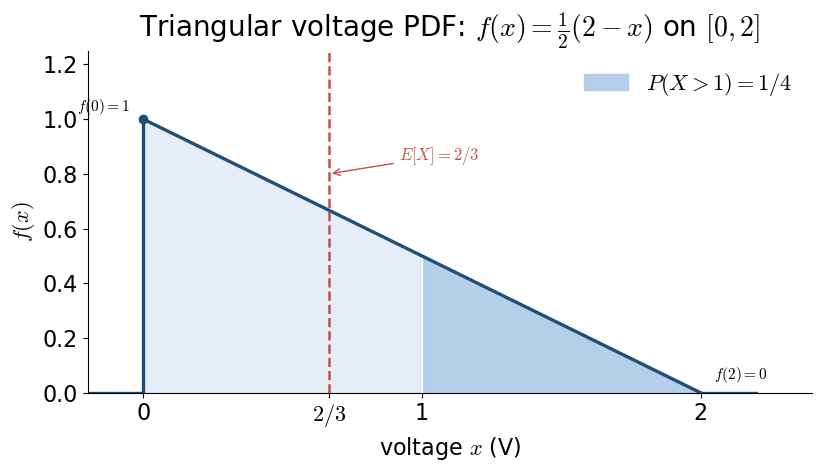

In [20]:
fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.linspace(0, 2, 200)
pdf = 0.5 * (2 - x)

ax.plot(x, pdf, color=C_PDF, lw=2.4)
ax.plot([-0.2, 0], [0, 0], color=C_PDF, lw=2.4)
ax.plot([2, 2.2], [0, 0], color=C_PDF, lw=2.4)
ax.plot([0, 0], [0, 1], color=C_PDF, lw=2.4)

x_tail = x[x >= 1]
pdf_tail = 0.5 * (2 - x_tail)
ax.fill_between(x_tail, 0, pdf_tail, color=C_FILL, alpha=0.85,
                label='$P(X > 1) = 1/4$')

x_head = x[x <= 1]
pdf_head = 0.5 * (2 - x_head)
ax.fill_between(x_head, 0, pdf_head, color=C_FILL, alpha=0.30)

EX = 2/3
ax.axvline(EX, color=C_MEAN, lw=1.8, ls='--')
ax.annotate(r'$E[X] = 2/3$', xy=(EX, 0.8), xytext=(EX + 0.25, 0.85),
            fontsize=12, color=C_MEAN,
            arrowprops=dict(arrowstyle='->', color=C_MEAN))

ax.plot(0, 1, 'o', color=C_PDF, ms=6)
ax.text(-0.05, 1.03, '$f(0) = 1$', fontsize=11, ha='right')
ax.text(2.05, 0.05, '$f(2) = 0$', fontsize=11, ha='left')

ax.set_xlim(-0.2, 2.4); ax.set_ylim(0, 1.25)
ax.set_xlabel('voltage $x$ (V)'); ax.set_ylabel('$f(x)$')
ax.set_xticks([0, EX, 1, 2]); ax.set_xticklabels(['0', '$2/3$', '1', '2'])
ax.set_title(r'Triangular voltage PDF: $f(x) = \frac{1}{2}(2 - x)$ on $[0, 2]$')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
fig.savefig('figures/06_triangle.png')
plt.show()


## Slide 11 — Exponential PDF for three rates

Shows the effect of $\lambda$. Large $\lambda \Rightarrow$ short waits, density piles up near zero. Small $\lambda \Rightarrow$ long waits, heavy tail. Dotted lines mark $E[X] = 1/\lambda$ for each curve.

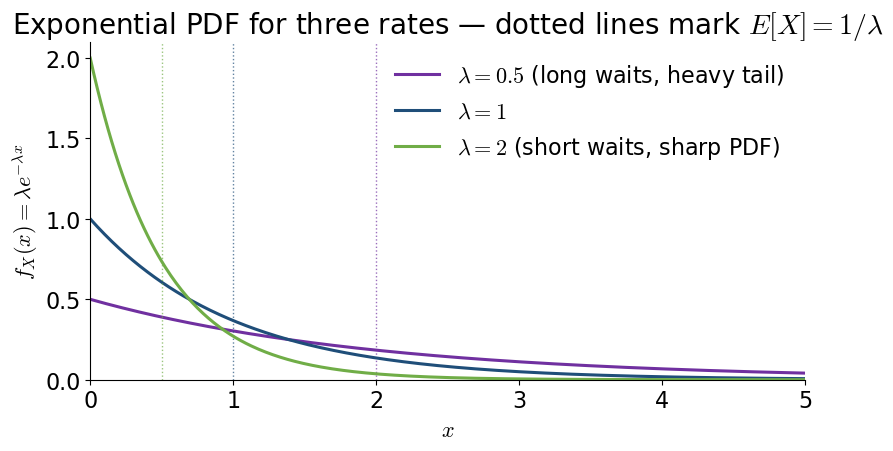

In [21]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
x = np.linspace(0, 5, 400)
for lam, color, label in [(0.5, C_ALT2, r'$\lambda = 0.5$ (long waits, heavy tail)'),
                          (1.0, C_PDF,  r'$\lambda = 1$'),
                          (2.0, C_ALT1, r'$\lambda = 2$ (short waits, sharp PDF)')]:
    pdf = lam * np.exp(-lam * x)
    ax.plot(x, pdf, lw=2.2, color=color, label=label)
    ax.axvline(1/lam, color=color, lw=1.0, ls=':', alpha=0.7)

ax.set_xlabel('$x$')
ax.set_ylabel(r'$f_X(x) = \lambda e^{-\lambda x}$')
ax.set_title(r'Exponential PDF for three rates — dotted lines mark $E[X] = 1/\lambda$')
ax.legend(frameon=False)
ax.set_xlim(0, 5); ax.set_ylim(0, 2.1)
fig.tight_layout()
fig.savefig('figures/07_exp_rates.png')
plt.show()


## Slide 11 — Meteorite first-strike example

Visualises the calculation $P(1/4 \leq X \leq 3/4) \approx 0.0476$ — a sliver of probability near zero, which makes sense given the mean is 10 days. Useful when the calculation might otherwise feel like a number plucked from the air.

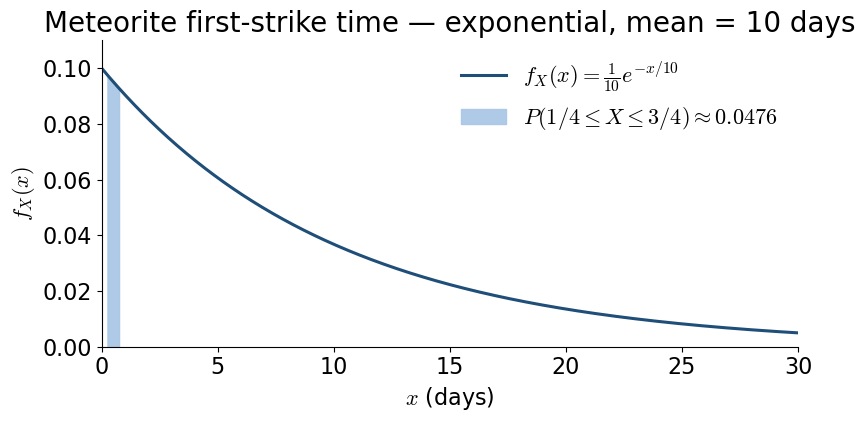

In [22]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
lam = 1/10
x = np.linspace(0, 30, 600)
pdf = lam * np.exp(-lam * x)
ax.plot(x, pdf, color=C_PDF, lw=2.2, label=r'$f_X(x) = \frac{1}{10} e^{-x/10}$')

a, b = 0.25, 0.75
xs = np.linspace(a, b, 100)
ax.fill_between(xs, 0, lam * np.exp(-lam * xs), color=C_FILL, alpha=0.95,
                label=r'$P(1/4 \leq X \leq 3/4) \approx 0.0476$')

ax.set_xlabel('$x$ (days)'); ax.set_ylabel('$f_X(x)$')
ax.set_title('Meteorite first-strike time — exponential, mean = 10 days')
ax.legend(loc='upper right', frameon=False)
ax.set_xlim(0, 30); ax.set_ylim(0, 0.11)
fig.tight_layout()
fig.savefig('figures/08_meteorite.png')
plt.show()


## Slides 13–14 — Discrete vs continuous CDF, side by side

The boardwork picture but rendered cleanly. Filled circles mark the value the CDF actually takes (right-continuity); open circles mark the limit-from-the-left. The annotated jump on the left and the tangent slope on the right are the two takeaways for slide 14.

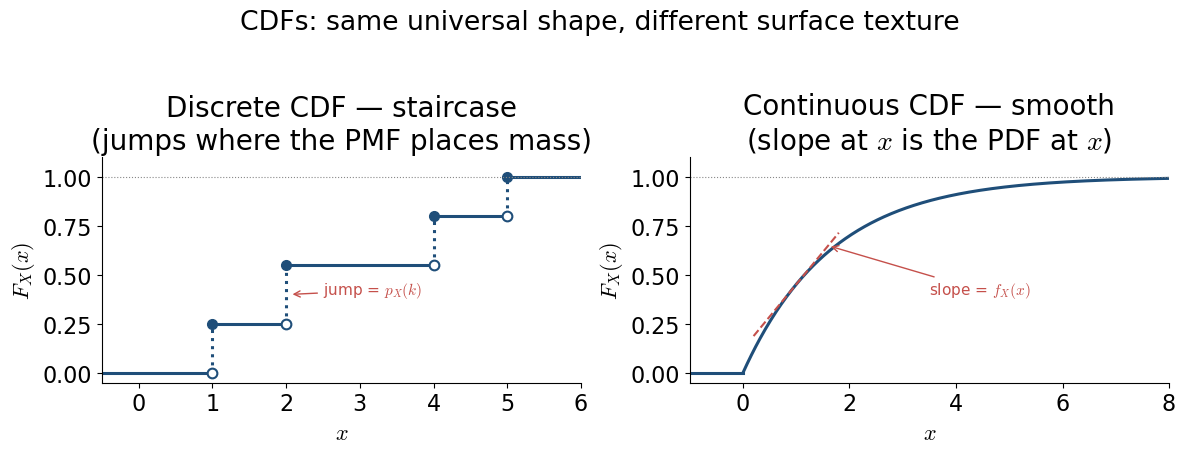

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Discrete CDF
ax = axes[0]
values = [1, 2, 4, 5]
probs = [0.25, 0.30, 0.25, 0.20]
cum = np.cumsum(probs)
x_lo, x_hi = -0.5, 6.0
prev_y = 0
ax.plot([x_lo, values[0]], [0, 0], color=C_PDF, lw=2.2)
for i, v in enumerate(values):
    ax.plot([v, v], [prev_y, cum[i]], color=C_PDF, lw=2.2, ls=':')
    next_x = values[i+1] if i + 1 < len(values) else x_hi
    ax.plot([v, next_x], [cum[i], cum[i]], color=C_PDF, lw=2.2)
    ax.plot(v, cum[i], 'o', color=C_PDF, ms=7)
    ax.plot(v, prev_y, 'o', mfc='white', mec=C_PDF, ms=7, mew=1.5)
    prev_y = cum[i]
ax.annotate('jump = $p_X(k)$', xy=(values[1] + 0.05, (cum[0] + cum[1]) / 2),
            xytext=(2.5, 0.40), fontsize=11, color=C_MEAN,
            arrowprops=dict(arrowstyle='->', color=C_MEAN))
ax.set_xlim(x_lo, x_hi); ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('$x$'); ax.set_ylabel('$F_X(x)$')
ax.set_title('Discrete CDF — staircase\n(jumps where the PMF places mass)')
ax.axhline(1.0, color=C_GREY, lw=0.8, ls=':')

# Continuous CDF
ax = axes[1]
lam = 0.6
x = np.linspace(0, 8, 400)
cdf = 1 - np.exp(-lam * x)
ax.plot([-1.0, 0], [0, 0], color=C_PDF, lw=2.2)
ax.plot(x, cdf, color=C_PDF, lw=2.2)
x0 = 1.0
y0 = 1 - np.exp(-lam * x0)
slope = lam * np.exp(-lam * x0)
xt = np.linspace(x0 - 0.8, x0 + 0.8, 50)
yt = y0 + slope * (xt - x0)
ax.plot(xt, yt, color=C_MEAN, lw=1.5, ls='--')
ax.annotate('slope = $f_X(x)$', xy=(x0 + 0.6, y0 + slope * 0.6),
            xytext=(3.5, 0.40), fontsize=11, color=C_MEAN,
            arrowprops=dict(arrowstyle='->', color=C_MEAN))
ax.set_xlim(-1.0, 8); ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('$x$'); ax.set_ylabel('$F_X(x)$')
ax.set_title('Continuous CDF — smooth\n(slope at $x$ is the PDF at $x$)')
ax.axhline(1.0, color=C_GREY, lw=0.8, ls=':')

fig.suptitle('CDFs: same universal shape, different surface texture', y=1.02)
fig.tight_layout()
fig.savefig('figures/09_cdf_compare.png')
plt.show()


## Slide 15 — Geometric vs exponential CDF

The big reveal. Geometric staircase ($p = 0.2$) and exponential smooth curve ($\lambda = -\ln(1-p) \approx 0.223$) trace out the same shape. The smooth curve passes through the right edge of every step — that's the precise mathematical statement that the geometric is the exponential, evaluated at integer times.

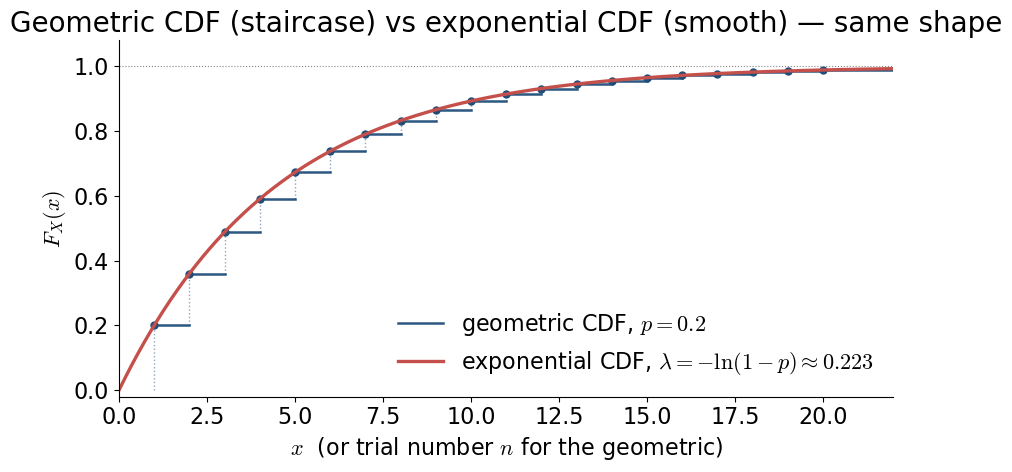

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))

p = 0.2
n_max = 20
n = np.arange(1, n_max + 1)
F_geo = 1 - (1 - p) ** n

for i, ni in enumerate(n):
    next_x = n[i+1] if i + 1 < len(n) else n_max + 2
    ax.plot([ni, next_x], [F_geo[i], F_geo[i]], color=C_PDF, lw=1.8, alpha=0.95,
            label='geometric CDF, $p = 0.2$' if i == 0 else None)
    ax.plot(ni, F_geo[i], 'o', color=C_PDF, ms=5)

prev_y = 0
for i, ni in enumerate(n):
    ax.plot([ni, ni], [prev_y, F_geo[i]], color=C_PDF, lw=1.0, ls=':', alpha=0.5)
    prev_y = F_geo[i]

lam = -np.log(1 - p)
x = np.linspace(0, n_max + 2, 600)
F_exp = 1 - np.exp(-lam * x)
ax.plot(x, F_exp, color=C_MEAN, lw=2.4,
        label=fr'exponential CDF, $\lambda = -\ln(1-p) \approx {lam:.3f}$')

ax.axhline(1.0, color=C_GREY, lw=0.8, ls=':')
ax.set_xlim(0, n_max + 2); ax.set_ylim(-0.02, 1.08)
ax.set_xlabel('$x$  (or trial number $n$ for the geometric)')
ax.set_ylabel('$F_X(x)$')
ax.set_title('Geometric CDF (staircase) vs exponential CDF (smooth) — same shape')
ax.legend(loc='lower right', frameon=False)
fig.tight_layout()
fig.savefig('figures/10_geo_vs_exp.png')
plt.show()


## Slide 15 — Median vs mean of the exponential

Visualises why the median ($\approx 6.93$ days) is well below the mean ($10$ days) for the meteorite example. The shaded region to the left of the median has area exactly 0.5; the heavy tail to the right pulls the centroid (mean) further right.

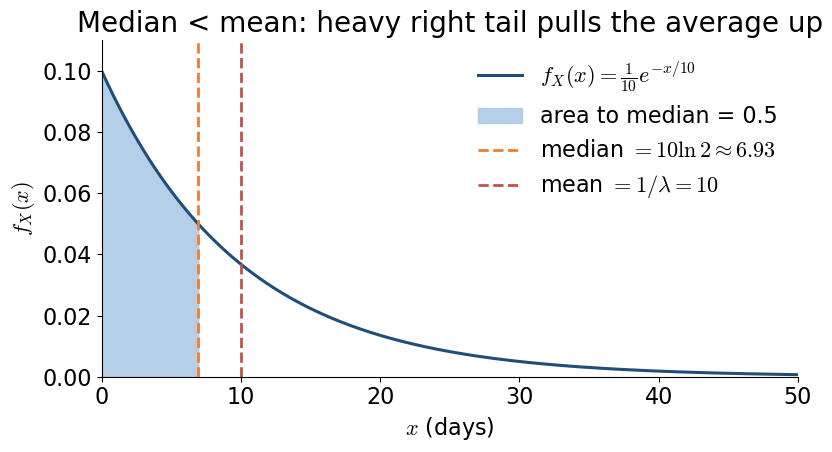

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
lam = 1/10
x = np.linspace(0, 50, 600)
pdf = lam * np.exp(-lam * x)
ax.plot(x, pdf, color=C_PDF, lw=2.2, label=r'$f_X(x) = \frac{1}{10} e^{-x/10}$')

median = 10 * np.log(2)
mean = 10
xs = np.linspace(0, median, 200)
ax.fill_between(xs, 0, lam * np.exp(-lam * xs), color=C_FILL, alpha=0.85,
                label='area to median = 0.5')
ax.axvline(median, color=C_MEDIAN, lw=2, ls='--',
           label=fr'median $= 10 \ln 2 \approx {median:.2f}$')
ax.axvline(mean, color=C_MEAN, lw=2, ls='--',
           label=fr'mean $= 1/\lambda = {mean}$')
ax.set_xlim(0, 50); ax.set_ylim(0, 0.11)
ax.set_xlabel('$x$ (days)'); ax.set_ylabel('$f_X(x)$')
ax.set_title('Median < mean: heavy right tail pulls the average up')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
fig.savefig('figures/11_median_vs_mean.png')
plt.show()


## Slide 16 (optional) — Memoryless property

The conditional density $f_{X|X>s}(x)$ is the original density shifted right by $s$ — same shape, no aging. If you run the optional closing slide, this picture is a quick way to make "memoryless" feel concrete.

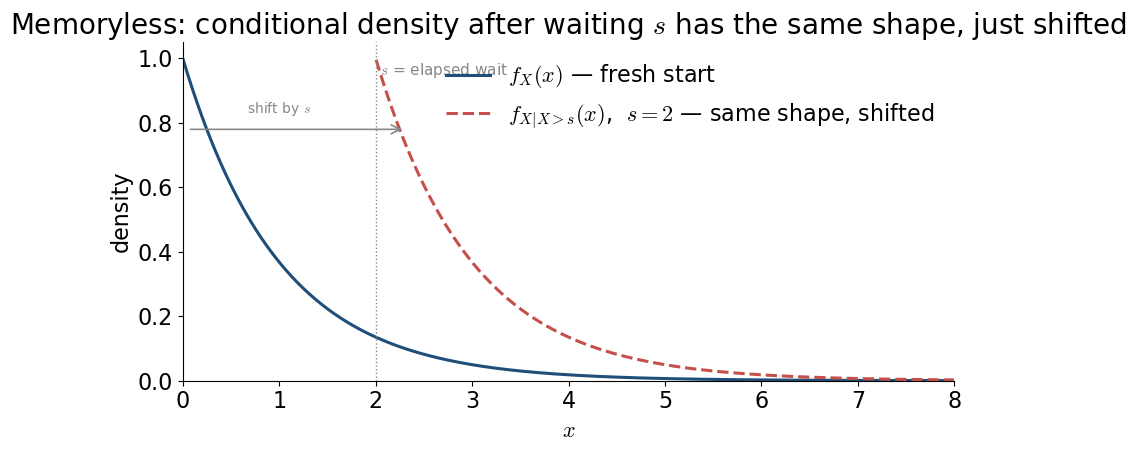

In [26]:
fig, ax = plt.subplots(figsize=(9, 4.8))
lam = 1.0
x = np.linspace(0, 8, 500)
pdf = lam * np.exp(-lam * x)
ax.plot(x, pdf, color=C_PDF, lw=2.2, label=r'$f_X(x)$ — fresh start')

s = 2.0
x2 = x[x >= s]
cond = lam * np.exp(-lam * (x2 - s))
ax.plot(x2, cond, color=C_MEAN, lw=2.2, ls='--',
        label=fr'$f_{{X|X>s}}(x)$,  $s = {s:.0f}$ — same shape, shifted')

ax.axvline(s, color=C_GREY, lw=1.0, ls=':')
ax.text(s + 0.05, 0.95, '$s$ = elapsed wait', color=C_GREY, fontsize=11)

ax.annotate('', xy=(s + 0.3, 0.78), xytext=(0.05, 0.78),
            arrowprops=dict(arrowstyle='->', color=C_GREY, lw=1.2))
ax.text(s/2, 0.83, 'shift by $s$', ha='center', color=C_GREY, fontsize=10)

ax.set_xlim(0, 8); ax.set_ylim(0, 1.05)
ax.set_xlabel('$x$'); ax.set_ylabel('density')
ax.set_title('Memoryless: conditional density after waiting $s$ has the same shape, just shifted')
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
fig.savefig('figures/12_memoryless.png')
plt.show()


## All figures saved

```
figures/01_pdf_intuition.png   figures/07_exp_rates.png
figures/02_pdf_unbounded.png   figures/08_meteorite.png
figures/03_uniform.png         figures/09_cdf_compare.png
figures/04_alvin.png           figures/10_geo_vs_exp.png
figures/05_quiz_q2.png         figures/11_median_vs_mean.png
figures/06_triangle.png        figures/12_memoryless.png
```

Drop into PowerPoint via Insert → Pictures, or right-click any rendered figure above and "Save as…". Edit colors/labels in the cell above each plot if needed and re-run.